<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part IV · Preparing Data &nbsp;|&nbsp; Chapter 24</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Feature Engineering <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five hands-on demos: one-hot encode a category, encode an ordinal one correctly (and see the trap), compare scalers against an outlier, bin a continuous variable two ways, and assemble a leakage-safe ColumnTransformer.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | One-hot encoding | a binary column per category; the cardinality cost |
| 2 | Ordinal vs the trap | order for ordinal data; false distance for nominal |
| 3 | Scalers vs an outlier | Standard / MinMax / Robust compared |
| 4 | Binning | equal-width (cut) vs equal-frequency (qcut) |
| 5 | A leakage-safe pipeline | ColumnTransformer, fit on train only |

> A feature is an input column a model learns from. The unifying rule: fit every transform on TRAIN data only.

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(24)
NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12.5,"axes.titleweight":"bold","axes.titlecolor":INK,"legend.frameon":False})
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · ONE-HOT ENCODING</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔣 A binary column per category</div>
<div style="color:#4a5578;margin-top:6px">Most models need numbers, not strings. One-hot encoding makes one 0/1 column per category, so no false order is implied, the right choice for NOMINAL data. pandas get_dummies is quick for EDA; sklearn OneHotEncoder remembers the categories so train and test stay consistent.</div>
</div>

In [2]:
df = pd.DataFrame({"city": ["NY","LA","SF","NY","LA"]})
print("get_dummies (quick, stateless):"); print(pd.get_dummies(df["city"], prefix="city").astype(int))

ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
X = ohe.fit_transform(df[["city"]])
print("\nOneHotEncoder columns (drop='first' avoids the dummy-variable trap):", list(ohe.get_feature_names_out()))

# the cardinality cost
high = pd.Series([f"id_{i % 400}" for i in range(3000)])   # 400 distinct values
print(f"\none-hot of {high.nunique()} categories -> {pd.get_dummies(high).shape[1]} columns (explosion!).")
print("For high cardinality, prefer target or frequency encoding instead.")

get_dummies (quick, stateless):
   city_LA  city_NY  city_SF
0        0        1        0
1        1        0        0
2        0        0        1
3        0        1        0
4        1        0        0

OneHotEncoder columns (drop='first' avoids the dummy-variable trap): ['city_NY', 'city_SF']

one-hot of 400 categories -> 400 columns (explosion!).
For high cardinality, prefer target or frequency encoding instead.


<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · ORDINAL VS THE TRAP</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔢 Order when it is real, not when it isn't</div>
<div style="color:#4a5578;margin-top:6px">Ordinal encoding maps categories to integers. That is correct when the order is real (S < M < L < XL): give OrdinalEncoder the order explicitly. It is a TRAP on nominal data, integer codes invent a false order and false distances that linear, KNN, and SVM models take literally.</div>
</div>

In [3]:
sizes = pd.DataFrame({"size": ["M","S","XL","L","S"]})
oe = OrdinalEncoder(categories=[["S","M","L","XL"]])      # state the real order
sizes["code"] = oe.fit_transform(sizes[["size"]]).astype(int)
print("Ordinal (order preserved: S=0, M=1, L=2, XL=3):"); print(sizes)

print("\nThe trap on NOMINAL data:")
colors = ["red","green","blue"]
codes = {c:i for i,c in enumerate(colors)}
print("  label-encode colors ->", codes)
print("  a linear/KNN model now reads blue(2) - red(0) = 2: a FAKE distance.")
print("  Nominal categories have NO order -> use one-hot, not integer codes.")

Ordinal (order preserved: S=0, M=1, L=2, XL=3):
  size  code
0    M     1
1    S     0
2   XL     3
3    L     2
4    S     0

The trap on NOMINAL data:
  label-encode colors -> {'red': 0, 'green': 1, 'blue': 2}
  a linear/KNN model now reads blue(2) - red(0) = 2: a FAKE distance.
  Nominal categories have NO order -> use one-hot, not integer codes.


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · SCALERS VS AN OUTLIER</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📏 Standard, MinMax, Robust</div>
<div style="color:#4a5578;margin-top:6px">Scaling puts features on a comparable footing for distance- and gradient-based models (KNN, SVM, neural nets); tree models do not need it. One outlier exposes the difference: StandardScaler and MinMaxScaler are pulled by it, while RobustScaler (median and IQR, Chapter 21) shrugs it off.</div>
</div>

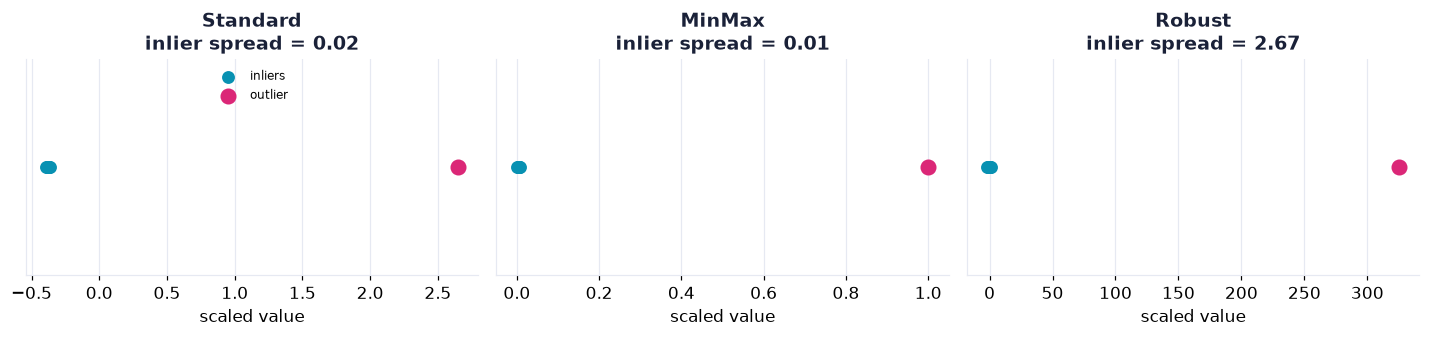

MinMax squashes the 7 inliers into a tiny corner near 0; RobustScaler keeps them spread out.


In [4]:
x = np.array([10, 12, 11, 13, 12, 14, 13, 500.0]).reshape(-1, 1)   # the 500 is an outlier
scalers = [("Standard", StandardScaler()), ("MinMax", MinMaxScaler()), ("Robust", RobustScaler())]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, (name, sc) in zip(axes, scalers):
    out = sc.fit_transform(x).ravel()
    ax.scatter(out[:-1], np.zeros(7), s=55, color=CYAN, label="inliers", zorder=3)
    ax.scatter([out[-1]], [0], s=90, color=PINK, label="outlier", zorder=4)
    span = out[:-1].max() - out[:-1].min()
    ax.set_title(f"{name}\ninlier spread = {span:.2f}"); ax.set_yticks([]); ax.set_xlabel("scaled value")
axes[0].legend(loc="upper center", fontsize=8)
plt.tight_layout(); plt.show()
print("MinMax squashes the 7 inliers into a tiny corner near 0; RobustScaler keeps them spread out.")

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · BINNING</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🪣 Equal-width vs equal-frequency</div>
<div style="color:#4a5578;margin-top:6px">Binning turns a continuous variable into categories. pd.cut makes equal-WIDTH bins (counts vary); pd.qcut makes equal-FREQUENCY bins (widths vary). Custom domain edges give interpretable groups. Binning aids interpretability but loses resolution, so modern models often skip it.</div>
</div>

In [5]:
ages = pd.Series([5, 8, 12, 18, 25, 31, 34, 45, 52, 67, 73, 80])

equal_width = pd.cut(ages, bins=4)
equal_freq  = pd.qcut(ages, q=4)
life_stage  = pd.cut(ages, bins=[0, 12, 19, 65, 120], labels=["child","teen","adult","senior"])

print("equal-WIDTH (pd.cut, bins=4) counts per bin:"); print(equal_width.value_counts().sort_index().to_string())
print("\nequal-FREQUENCY (pd.qcut, q=4) counts per bin:"); print(equal_freq.value_counts().sort_index().to_string())
print("\ncustom life-stage bins:"); print(life_stage.value_counts().sort_index().to_string())

equal-WIDTH (pd.cut, bins=4) counts per bin:
(4.925, 23.75]    4
(23.75, 42.5]     3
(42.5, 61.25]     2
(61.25, 80.0]     3

equal-FREQUENCY (pd.qcut, q=4) counts per bin:
(4.999, 16.5]    3
(16.5, 32.5]     3
(32.5, 55.75]    3
(55.75, 80.0]    3

custom life-stage bins:
child     3
teen      1
adult     5
senior    3


<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · A LEAKAGE-SAFE PIPELINE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🚰 Different transforms, fit on train only</div>
<div style="color:#4a5578;margin-top:6px">Real datasets mix numeric and categorical columns. A ColumnTransformer applies a scaler to the numbers and a one-hot encoder to the categories in one object, and fitting it on the TRAINING data only keeps the scaler stats and category list out of the test set, the same no-leakage rule from Chapters 12, 20, 21 and 22.</div>
</div>

In [6]:
data = pd.DataFrame({
    "age":    rng.integers(18, 70, 200),
    "income": rng.normal(60, 18, 200).round(1),
    "city":   rng.choice(["NY","LA","SF","CHI"], 200),
})
X_train, X_test = train_test_split(data, test_size=0.25, random_state=0)

pre = ColumnTransformer([
    ("num", StandardScaler(), ["age", "income"]),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["city"]),
])
pre.fit(X_train)                       # learns scaler stats + categories from TRAIN ONLY
Xtr = pre.transform(X_train); Xte = pre.transform(X_test)
print("output feature names:", list(pre.get_feature_names_out()))
print(f"train shape {Xtr.shape}, test shape {Xte.shape}")
print("\nWrap this in a Pipeline([...preprocess..., model]) and the fit-on-train-only rule holds automatically inside cross-validation.")

output feature names: ['num__age', 'num__income', 'cat__city_CHI', 'cat__city_LA', 'cat__city_NY', 'cat__city_SF']
train shape (150, 6), test shape (50, 6)

Wrap this in a Pipeline([...preprocess..., model]) and the fit-on-train-only rule holds automatically inside cross-validation.


## 🛒 Real-World Example: From Raw Orders to Features
Five raw columns, a timestamp, a customer, a category, and an amount, are not much for a model to learn from. Feature engineering fixes that: we pull **calendar parts** out of the timestamp, take a **log** of the skewed amount, **one-hot** the category, and compute a per-customer **running order count**. Watch five columns become more than a dozen model-ready features, and watch a derived feature (hour of day) reveal a pattern the raw table hid.

raw columns: 5   ->   engineered model features: 10
new features: ['hour', 'dayofweek', 'is_weekend', 'log_amount', 'cust_order_count', 'cat_Books', 'cat_Clothing', 'cat_Electronics', 'cat_Home', 'cat_Toys']


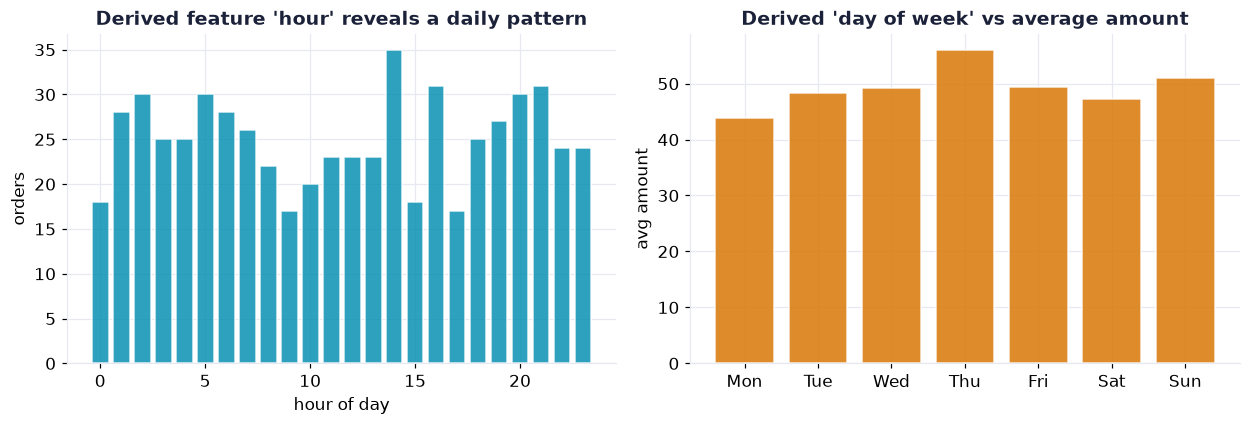

In [7]:
# --- Real-World beat: engineer features from raw orders ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    orders = pd.read_excel("../../data/feature-engineering--raw_orders.xlsx", sheet_name="Data")
except FileNotFoundError: orders = pd.read_excel(BASE+"feature-engineering--raw_orders.xlsx", sheet_name="Data")
orders["order_datetime"] = pd.to_datetime(orders["order_datetime"])
f = orders.copy()
f["hour"] = f.order_datetime.dt.hour                                  # calendar parts
f["dayofweek"] = f.order_datetime.dt.dayofweek
f["is_weekend"] = (f.dayofweek >= 5).astype(int)
f["log_amount"] = np.log1p(f.amount)                                 # tame the skew
f["cust_order_count"] = f.sort_values("order_datetime").groupby("customer_id").cumcount() + 1   # per-customer aggregate
f = pd.concat([f, pd.get_dummies(f.product_category, prefix="cat").astype(int)], axis=1)          # one-hot
model_cols = [c for c in f.columns if c not in ["order_id","order_datetime","customer_id","product_category","amount"]]
print(f"raw columns: {orders.shape[1]}   ->   engineered model features: {len(model_cols)}")
print("new features:", model_cols)
fig, ax = plt.subplots(1, 2, figsize=(11.5,4))
by_hour = f.groupby("hour").size()
ax[0].bar(by_hour.index, by_hour.values, color=CYAN, alpha=0.85, edgecolor="white")
ax[0].set_title("Derived feature 'hour' reveals a daily pattern"); ax[0].set_xlabel("hour of day"); ax[0].set_ylabel("orders")
by_dow = f.groupby("dayofweek").amount.mean().reindex(range(7))
ax[1].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], by_dow.values, color=AMBER, alpha=0.85, edgecolor="white")
ax[1].set_title("Derived 'day of week' vs average amount"); ax[1].set_ylabel("avg amount")
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>One-hot</b> encoding suits nominal data (no false order); watch the column explosion at high cardinality.</li>
<li><b>Ordinal</b> encoding is right when order is real; on nominal data it invents false distances, use one-hot.</li>
<li><b>Scale</b> for distance/gradient models (not trees); <b>RobustScaler</b> resists outliers.</li>
<li><b>Binning</b> (cut equal-width, qcut equal-frequency) aids interpretability but loses resolution.</li>
<li>Use a <b>ColumnTransformer + Pipeline</b> and fit on <b>train only</b> to prevent leakage.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>